# Project Canary: Three-Model Evaluation

## tl;dr

Canary retains **two business outcomes** while evaluating **three engines**. Reconstructed Model 1 remains experimental because it did not beat its transparent recovery baseline. Reconstructed Model 3 is a useful Day 21 shadow benchmark. For the primary checkpoint bodyweight outlook, the transparent historical remaining-gain method remains the champion: more complex learned and THI-inclusive candidates did not produce a stable enough improvement to justify replacing it.


## Context & Methods

### Key assumptions

- Thirty-one building-cycles from 2025-2 through 2026-2 form the development cohort.
- The three buildings from 2026-3 stay together as one later-cycle audit.
- Validation holds out complete production cycles; preprocessing and candidate tuning stay inside training folds.
- Model 1 uses Canary's canonical last-recorded-population recovery proxy.
- THI features are predictive candidates, not causal evidence or approved action thresholds.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
EXPERIMENT = ROOT / "outputs" / "three_model_evaluation"
LEGACY = EXPERIMENT / "legacy"
CHECKPOINT = EXPERIMENT / "checkpoint_champion"

model_1 = json.loads((LEGACY / "model_1_manifest.json").read_text())
model_3 = json.loads((LEGACY / "model_3_manifest.json").read_text())
checkpoint = json.loads((CHECKPOINT / "manifest.json").read_text())
comparison = pd.read_csv(CHECKPOINT / "model_comparison.csv")
checkpoint_metrics = pd.DataFrame(checkpoint["checkpoint_metrics"])


Matplotlib is building the font cache; this may take a moment.


## Data

In [2]:
cohort = pd.DataFrame([
    {"Evidence": "Development", "Production cycles": len(model_1["development_cycles"]), "Building outcomes": model_1["development_building_cycles"]},
    {"Evidence": "Later-cycle audit", "Production cycles": 1, "Building outcomes": model_1["audit_buildings"]},
])
cohort


,Evidence,Production cycles,Building outcomes
0,Development,6,31
1,Later-cycle audit,1,3


In [3]:
assert model_1["development_building_cycles"] == 31
assert model_3["development_building_cycles"] == 31
assert model_1["audit_cycle"] == model_3["audit_cycle"] == "2026-3"
assert checkpoint["quality_profile"]["development_outcomes"] == 31
assert checkpoint["quality_profile"]["later_cycle_outcomes"] == 3
print("Cohort and audit boundaries verified.")


Cohort and audit boundaries verified.


## Results

In [4]:
summary = pd.DataFrame([
    {
        "Engine": "Reconstructed Model 1",
        "Outcome": "Recovery proxy",
        "Review points": "Days 7 and 14",
        "Development MAE": f'{model_1["selected_metrics"]["mae"] * 100:.2f} pp',
        "Later-cycle audit MAE": f'{model_1["audit_metrics"]["mae"] * 100:.2f} pp',
        "Status": model_1["status"],
    },
    {
        "Engine": "Reconstructed Model 3",
        "Outcome": "Day 35 bodyweight",
        "Review points": "Day 21",
        "Development MAE": f'{model_3["selected_metrics"]["mae"]:.0f} g',
        "Later-cycle audit MAE": f'{model_3["audit_metrics"]["mae"]:.0f} g',
        "Status": model_3["status"],
    },
    {
        "Engine": "Checkpoint champion",
        "Outcome": "Day 35 bodyweight",
        "Review points": "Days 7, 14, 21 and 28",
        "Development MAE": f'{checkpoint["champion_metrics"]["mae_g"]:.0f} g',
        "Later-cycle audit MAE": f'{checkpoint["later_cycle_audit_metrics"]["mae_g"]:.0f} g',
        "Status": "pilot-ready baseline",
    },
])
summary


,Engine,Outcome,Review points,Development MAE,Later-cycle audit MAE,Status
0,Reconstructed Model 1,Recovery proxy,Days 7 and 14,2.47 pp,4.55 pp,experimental
1,Reconstructed Model 3,Day 35 bodyweight,Day 21,146 g,116 g,shadow
2,Checkpoint champion,Day 35 bodyweight,"Days 7, 14, 21 and 28",127 g,78 g,pilot-ready baseline


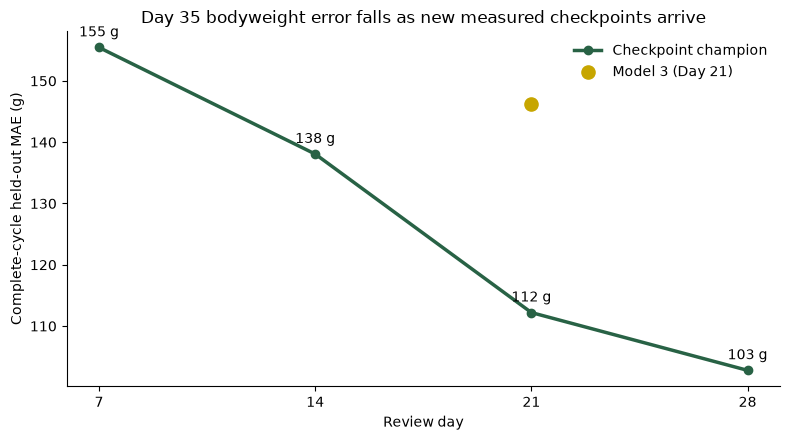

In [5]:
plot = checkpoint_metrics[["review_day", "mae_g"]].copy()
model3_day21 = model_3["selected_metrics"]["mae"]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot["review_day"], plot["mae_g"], marker="o", linewidth=2.5, color="#286245", label="Checkpoint champion")
ax.scatter([21], [model3_day21], s=90, color="#c7a600", label="Model 3 (Day 21)", zorder=3)
for x, y in zip(plot["review_day"], plot["mae_g"]):
    ax.annotate(f"{y:.0f} g", (x, y), xytext=(0, 8), textcoords="offset points", ha="center")
ax.set(title="Day 35 bodyweight error falls as new measured checkpoints arrive", xlabel="Review day", ylabel="Complete-cycle held-out MAE (g)", xticks=[7, 14, 21, 28])
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [6]:
comparison[["candidate", "family", "feature_set", "cycle_macro_rmse_g", "cycle_macro_mae_g", "r2"]].head(10)


,candidate,family,feature_set,cycle_macro_rmse_g,cycle_macro_mae_g,r2
0,direct_extra_trees_growth,extra_trees,compact,140.501899,117.127053,0.294923
1,remaining_trajectory_ridge,ridge,trajectory,146.977126,122.176161,0.326375
2,historical_remaining_gain,baseline,current,149.908272,120.927604,0.310130
3,recent_adg_projection,recent_adg,compact,149.908272,120.927604,0.310130
4,blend_baseline_pls,blend,trajectory,149.919367,123.898329,0.310626
5,direct_linear_svr,svr,trajectory,152.478324,131.799899,0.059595
6,direct_trajectory_ridge,ridge,trajectory,154.900552,127.963552,0.237804
7,direct_current_weight_ols,ols,current,155.909837,134.860350,0.315099
8,direct_extra_trees,extra_trees,extended,156.853115,133.627136,0.107949
9,direct_gradient_boosting,gradient_boosting,extended,157.126143,134.104873,0.088652


### THI finding

The original Model 1 and Model 3 schemas retain maximum daily/cycle THI and THI stress-day features. The checkpoint tournament also tested wet-bulb-based THI history, maximum THI, stress-day share, and compound heat-humidity exposure. THI-inclusive candidate families did not outperform the selected transparent checkpoint baseline. This does not show that THI is biologically unimportant; it shows that the current sample and environmental coverage do not support giving THI additional predictive or operating authority yet.


## Takeaways

1. Keep Model 1 visible only as an **experimental** recovery-proxy outlook.
2. Keep Model 3 as a **Day 21 shadow benchmark**, not the main bodyweight forecast.
3. Use historical remaining gain as the provisional checkpoint bodyweight method at Days 7, 14, 21 and 28.
4. Continue collecting standardized weight and environment records. Re-evaluate the learned Extra Trees challenger and THI-inclusive candidates after additional complete cycles.
5. Keep all forecasts independent from the observed-condition risk score.
